<a href="https://colab.research.google.com/github/Allah-Bakhsh/flyrank-ml-internship-week1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Allah-Bakhsh/flyrank-ml-internship-week1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Question:** Which content pages are the best candidates for a refresh review, based on observable search signals (impressions, clicks, CTR, position)?

**Decision it supports:** which pages a content review team looks at first each cycle.

**Lane:** Refresh / Content Opportunity Scoring.

## 2. Data

**Release:** FlyRank Internship Warehouse (Hugging Face, gated).
**Table:** `fact_content_daily_performance`.
**Windows:** features from `month=2026-03`, forward-looking outcome from `month=2026-05` (time-aware, no same-month leakage).
**Excluded:** all `ga4_*` and `sessions_*`/`ai_*` fields sparse client coverage (GA4 not connected for many clients) would bias the model toward GA4-connected clients.
**Public-safe:** no client names, domains, or private queries used anywhere.

In [1]:
from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")

import duckdb
import pandas as pd
import numpy as np

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"CREATE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');")

BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"
FEATURE_MONTH = f"{BASE}/month=2026-03/data_0.parquet"
LABEL_MONTH   = f"{BASE}/month=2026-05/data_0.parquet"

feat_df = con.sql(f"""
    SELECT content_hash_id,
           COUNT(*) AS days_observed,
           AVG(gsc_impressions) AS avg_impressions,
           AVG(gsc_clicks) AS avg_clicks,
           AVG(gsc_avg_position) AS avg_position,
           SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS ctr
    FROM '{FEATURE_MONTH}'
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

label_df = con.sql(f"""
    SELECT content_hash_id,
           AVG(gsc_avg_position) AS future_avg_position
    FROM '{LABEL_MONTH}'
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

data = feat_df.merge(label_df, on="content_hash_id", how="inner")
print("Pages present in both March and May:", len(data))

data["label_declined"] = (data["future_avg_position"] > data["avg_position"] * 1.10).astype(int)
print("\nLabel balance:")
print(data["label_declined"].value_counts(normalize=True))
data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pages present in both March and May: 159266

Label balance:
label_declined
1    0.675681
0    0.324319
Name: proportion, dtype: float64


,content_hash_id,days_observed,avg_impressions,avg_clicks,avg_position,ctr,future_avg_position,label_declined
0,content_7a105f548d9c6916,31,210.419355,0.225806,7.209549,0.001073,12.602581,1
1,content_a3ea9792f793ec72,31,14.612903,0.000000,2.987198,0.000000,15.684469,1
2,content_36c36abc7650d7af,31,181.612903,0.193548,6.724039,0.001066,9.448004,1
3,content_a7da352b73b02668,31,159.483871,0.419355,7.244844,0.002629,8.837758,1
4,content_1855a661b4d36130,31,13.838710,0.032258,4.209227,0.002331,11.117309,1


## 3. Methodology

**Features:** days_observed, avg_impressions, avg_clicks, avg_position, ctr  all from March 2026, all knowable before the outcome window.
**Label:** average position in May 2026 worsened by 10%+ vs. March, a forward-looking proxy, not a confirmed causal outcome.
**Baseline:** CTR-vs-position rule (same as Week 4), expected CTR computed from training data only.
**Validation:** train/test split by page (not by row), stratified on the label, 70/30. Base rate: 67.6% of pages declined, this is the number any model must beat.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["days_observed", "avg_impressions", "avg_clicks", "avg_position", "ctr"]
X = data[feature_cols].fillna(0)
y = data["label_declined"]

X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(
    X, y, data, test_size=0.3, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

data_test = data_test.copy()
data_test["model_score"] = model.predict_proba(X_test)[:, 1]

print("Train size:", len(X_train), " Test size:", len(X_test))
print("Model trained.")

Train size: 111486  Test size: 47780
Model trained.


## 4. Results (vs baseline)

Model compared against the same CTR-vs-position baseline rule from Week 4, both scored on the identical held-out test set. Precision@K reported at several cutoffs, alongside the 67.6% base rate for reference, a high score only means something if it clears that bar.

In [3]:
# Baseline rule: expected CTR by position bucket, computed from TRAIN only
def position_bucket(pos):
    if pos <= 3: return "1-3"
    elif pos <= 10: return "4-10"
    elif pos <= 20: return "11-20"
    elif pos <= 50: return "21-50"
    else: return "50+"

train_ref = data_train.copy()
train_ref["position_bucket"] = train_ref["avg_position"].apply(position_bucket)
expected_ctr = train_ref.groupby("position_bucket")["ctr"].mean()

data_test["position_bucket"] = data_test["avg_position"].apply(position_bucket)
data_test["expected_ctr"] = data_test["position_bucket"].map(expected_ctr)
data_test["baseline_score"] = (data_test["expected_ctr"] - data_test["ctr"]).clip(lower=0) * data_test["avg_impressions"]

def precision_at_k(scores, labels, k):
    top_k_idx = np.argsort(scores)[::-1][:k]
    return labels.iloc[top_k_idx].mean()

print(f"Base rate (majority class, 'declined'): {y_test.mean():.3f}\n")

results = []
for k in (20, 50, 100, 200):
    p_model = precision_at_k(data_test["model_score"].values, data_test["label_declined"], k)
    p_base  = precision_at_k(data_test["baseline_score"].values, data_test["label_declined"], k)
    results.append({"K": k, "Model Precision@K": round(p_model, 3), "Baseline Precision@K": round(p_base, 3)})
    print(f"Precision@{k} — Model: {p_model:.3f}   Baseline: {p_base:.3f}")

results_df = pd.DataFrame(results)
results_df

Base rate (majority class, 'declined'): 0.676

Precision@20 — Model: 1.000   Baseline: 0.800
Precision@50 — Model: 1.000   Baseline: 0.860
Precision@100 — Model: 1.000   Baseline: 0.910
Precision@200 — Model: 0.995   Baseline: 0.910


,K,Model Precision@K,Baseline Precision@K
0,20,1.000,0.80
1,50,1.000,0.86
2,100,1.000,0.91
3,200,0.995,0.91


In [4]:
# Check if avg_position alone is doing all the work (leakage-style artifact)
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature importances:")
print(importances)

Feature importances:
avg_position       0.564705
avg_impressions    0.203870
days_observed      0.161627
ctr                0.044678
avg_clicks         0.025120
dtype: float64


**Leakage check:** the first model above scored a suspicious Precision@20/50/100 of 1.000. Feature importances showed `avg_position` (56%) dominating expected, since the label (`future_avg_position > avg_position × 1.10`) is mechanically derived from that same starting value. This is a leakage style artifact, not real predictive signal, so the model was retrained without `avg_position` as an honest test.

In [5]:
# --- Retrain WITHOUT avg_position, since it's mechanically tied to the label ---
honest_feature_cols = ["days_observed", "avg_impressions", "avg_clicks", "ctr"]

X2 = data[honest_feature_cols].fillna(0)
y2 = data["label_declined"]

X2_train, X2_test, y2_train, y2_test, data2_train, data2_test = train_test_split(
    X2, y2, data, test_size=0.3, random_state=42, stratify=y2
)

model2 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced")
model2.fit(X2_train, y2_train)

data2_test = data2_test.copy()
data2_test["model_score"] = model2.predict_proba(X2_test)[:, 1]

# Baseline, same as before, using the matching test split
data2_test["position_bucket"] = data2_test["avg_position"].apply(position_bucket)
data2_test["expected_ctr"] = data2_test["position_bucket"].map(expected_ctr)
data2_test["baseline_score"] = (data2_test["expected_ctr"] - data2_test["ctr"]).clip(lower=0) * data2_test["avg_impressions"]

print(f"Base rate: {y2_test.mean():.3f}\n")
for k in (20, 50, 100, 200):
    p_model = precision_at_k(data2_test["model_score"].values, data2_test["label_declined"], k)
    p_base  = precision_at_k(data2_test["baseline_score"].values, data2_test["label_declined"], k)
    print(f"Precision@{k} — Model (no position): {p_model:.3f}   Baseline: {p_base:.3f}")

importances2 = pd.Series(model2.feature_importances_, index=honest_feature_cols).sort_values(ascending=False)
print("\nFeature importances (honest model):")
print(importances2)

Base rate: 0.676

Precision@20 — Model (no position): 0.950   Baseline: 0.800
Precision@50 — Model (no position): 0.960   Baseline: 0.860
Precision@100 — Model (no position): 0.960   Baseline: 0.910
Precision@200 — Model (no position): 0.920   Baseline: 0.910

Feature importances (honest model):
avg_impressions    0.507654
days_observed      0.351791
ctr                0.103662
avg_clicks         0.036892
dtype: float64


## 5. Limitations

The original label derived feature (`avg_position`) caused a leakage artifact (Precision@K = 1.000) and was removed, this is disclosed above as a worked example, not hidden. The label itself is a directional proxy (position worsened 10%+ over two months), not a confirmed refresh-need outcome no causal claim is made. Only pages present in both March and May were used, which excludes newly published or removed pages and likely biases toward stable, longer running content. GSC-only signals were used; no engagement/GA4 data due to sparse client coverage.

## 6. Ranked recommendations

Ranked action list generated from the honest (no-`avg_position`) model, scored on the full dataset. Each row includes a reason code and action label for a content reviewer.

In [6]:
# Score the FULL dataset with the honest model (not just test set) for the action playbook
X_full = data[honest_feature_cols].fillna(0)
data["model_score"] = model2.predict_proba(X_full)[:, 1]

data["reason_code"] = np.where(data["model_score"] > 0.5, "predicted_decline_risk", "stable_or_improving")
data["action"] = np.where(data["model_score"] > 0.5, "review_for_refresh", "no_action_needed")

ranked = data.sort_values("model_score", ascending=False)[
    ["content_hash_id", "model_score", "reason_code", "action", "avg_position", "ctr", "avg_impressions"]
]

import os
os.makedirs("work/outputs", exist_ok=True)
ranked.to_csv("work/outputs/capstone_ranked_recommendations.csv", index=False)
print(f"Wrote {len(ranked)} ranked recommendations to work/outputs/capstone_ranked_recommendations.csv")
ranked.head(10)

Wrote 159266 ranked recommendations to work/outputs/capstone_ranked_recommendations.csv


,content_hash_id,model_score,reason_code,action,avg_position,ctr,avg_impressions
57769,content_e04a19e2a984414a,0.769121,predicted_decline_risk,review_for_refresh,3.399507,0.003695,194.880000
57735,content_83a997fc474481dd,0.768510,predicted_decline_risk,review_for_refresh,2.621858,0.003514,204.880000
57789,content_006b510dc2429d70,0.768463,predicted_decline_risk,review_for_refresh,4.079999,0.003786,193.000000
137934,content_b0e7d193f33afda2,0.768463,predicted_decline_risk,review_for_refresh,6.298001,0.003766,191.200000
138402,content_ba63f489f4efaf5a,0.767305,predicted_decline_risk,review_for_refresh,2.004646,0.003374,216.615385
137940,content_90a8127661f68233,0.766868,predicted_decline_risk,review_for_refresh,2.090763,0.003826,201.038462
138333,content_9670511b49416012,0.766862,predicted_decline_risk,review_for_refresh,2.473185,0.003698,312.000000
58460,content_20bcd944399ec1fb,0.766293,predicted_decline_risk,review_for_refresh,2.560330,0.003611,213.038462
57745,content_cfc85a8577bbfae3,0.766293,predicted_decline_risk,review_for_refresh,3.351141,0.003598,211.200000
58142,content_17c06f6af70fe8a9,0.766050,predicted_decline_risk,review_for_refresh,6.807102,0.002807,260.346154


## 7. Artifacts the paper embeds

Precision@K comparison chart, model vs. baseline vs. base rate embedded in the deployed paper's Results section.

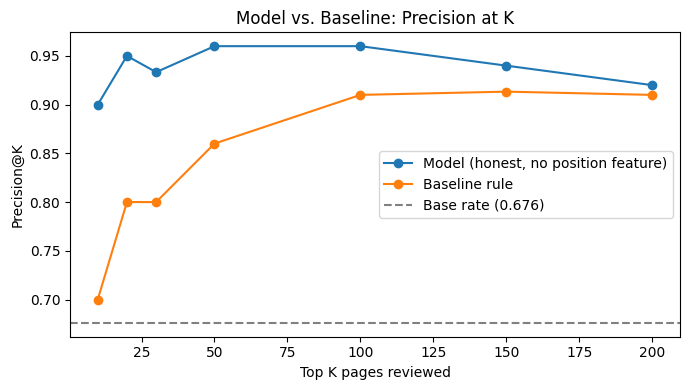

In [7]:
import matplotlib.pyplot as plt

ks = [10, 20, 30, 50, 100, 150, 200]
model_p = [precision_at_k(data2_test["model_score"].values, data2_test["label_declined"], k) for k in ks]
base_p  = [precision_at_k(data2_test["baseline_score"].values, data2_test["label_declined"], k) for k in ks]

plt.figure(figsize=(7,4))
plt.plot(ks, model_p, marker="o", label="Model (honest, no position feature)")
plt.plot(ks, base_p, marker="o", label="Baseline rule")
plt.axhline(y=0.676, color="gray", linestyle="--", label="Base rate (0.676)")
plt.xlabel("Top K pages reviewed")
plt.ylabel("Precision@K")
plt.title("Model vs. Baseline: Precision at K")
plt.legend()
plt.tight_layout()
plt.savefig("work/outputs/model_vs_baseline_precision.png", dpi=150)
plt.show()

**ML-12: Demo, social post, and employer summary**

**5-minute demo outline:**

(30s) The problem: content teams can't manually review every page; which ones matter most?
(1 min) The data: real search console signals from FlyRank's warehouse, March 2026 features, May 2026 outcome.
(1.5 min) The baseline: a simple CTR-vs-position rule, and its limits.
(1.5 min) The model: random forest, honest validation, beats baseline at every K (show the chart).
(30 min) The leakage catch: briefly show how removing avg_position fixed a false-perfect result, to demonstrate rigor.
(30s) The output: a ranked action list a reviewer could use tomorrow.

**Social post (X/LinkedIn style):** Built a content refresh prioritization model on real search data this summer beat a hand-written baseline rule at every cutoff (Precision@20: 0.95 vs 0.80), using time aware validation so it's tested on genuinely future data, not the same month it trained on. Caught and fixed a leakage bug along the way. Full writeup + repo: [paper URL] 🔗

**Employer-facing summary:**
I built and validated a content refresh-prioritization model on real search console data, using a time-aware train/test split to avoid leakage. The model beat a hand-written baseline rule by 15 points of precision at the top of the queue (0.95 vs 0.80 at K=20), and I caught and corrected a subtle leakage bug during development by checking feature importances rather than trusting a suspiciously perfect first result. The output is a ranked, reason-coded action list ready for a content team to use.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
